In [ ]:
import os
import numpy as np
from scipy.signal import butter, filtfilt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt

In [ ]:
FS = 128
EPOCH_SEC = 8
BAND = (0.5, 45)

ROOT = "EEG_data"
HEALTHY_FOLDERS = ["Eyes_closed", "healthy_output"]
AD_FOLDER = "Eyes_closed"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHANNELS = [
    "Fp1","Fp2","F3","F4","F7","F8","Fz",
    "C3","C4","Cz",
    "P3","P4","Pz",
    "T3","T4","T5","T6",
    "O1","O2"
]

In [ ]:
def butter_bandpass(low, high, fs, order=6):
    nyq = 0.5 * fs
    return butter(order, [low/nyq, high/nyq], btype="band")

def bandpass_filter(eeg):
    b, a = butter_bandpass(*BAND, FS)
    eeg = filtfilt(b, a, eeg, axis=0)
    eeg = (eeg - np.mean(eeg, axis=0)) / (np.std(eeg, axis=0) + 1e-8)
    return eeg.astype(np.float32)

In [ ]:
def epoch_signal(eeg):
    samples = FS * EPOCH_SEC
    epochs = []

    for i in range(0, eeg.shape[0], samples):
        ep = eeg[i:i+samples]
        if ep.shape[0] == samples:
            epochs.append(ep)

    return np.array(epochs)

In [ ]:
def load_patient(folder):
    signals = []

    for ch in CHANNELS:
        path = os.path.join(folder, f"{ch}.txt")
        if not os.path.exists(path):
            return None
        signals.append(np.loadtxt(path))

    return np.stack(signals, axis=1)

In [ ]:
def load_all():
    X, y = [], []

    healthy_base = os.path.join(ROOT, "Healthy")

    for folder in HEALTHY_FOLDERS:
        base = os.path.join(healthy_base, folder)

        if not os.path.exists(base):
            continue

        for patient in os.listdir(base):
            pdir = os.path.join(base, patient)

            eeg = load_patient(pdir)
            if eeg is None:
                continue

            eeg = bandpass_filter(eeg)
            epochs = epoch_signal(eeg)

            if len(epochs) > 0:
                X.append(epochs)
                y.append(0)

    ad_base = os.path.join(ROOT, "AD", AD_FOLDER)

    for patient in os.listdir(ad_base):
        pdir = os.path.join(ad_base, patient)

        eeg = load_patient(pdir)
        if eeg is None:
            continue

        eeg = bandpass_filter(eeg)
        epochs = epoch_signal(eeg)

        if len(epochs) > 0:
            X.append(epochs)
            y.append(1)

    print("Loaded", len(X), "subjects")
    return X, np.array(y)

In [ ]:
def prepare_dnn_data(Xp, yp, max_epochs_per_subject=50):
    healthy_X, ad_X = [], []

    for i in range(len(Xp)):
        epochs = Xp[i]

        if len(epochs) > max_epochs_per_subject:
            idx = np.random.choice(len(epochs), max_epochs_per_subject, replace=False)
            epochs = epochs[idx]

        for ep in epochs:
            if yp[i] == 0:
                healthy_X.append(ep)
            else:
                ad_X.append(ep)

    healthy_X = np.array(healthy_X)
    ad_X = np.array(ad_X)

    # 🔥 PARTIAL OVERSAMPLING (KEY FIX)
    target_size = int(len(healthy_X) * 0.8)
    if len(ad_X) < target_size:
        idx = np.random.choice(len(ad_X), target_size, replace=True)
        ad_X = ad_X[idx]

    X = np.concatenate([healthy_X, ad_X])
    y = np.array([0]*len(healthy_X) + [1]*len(ad_X))

    X = X.reshape(X.shape[0], -1)

    # Standard normalization
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0) + 1e-8
    X = (X - mean) / std

    idx = np.random.permutation(len(y))
    return X[idx], y[idx]

In [ ]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
class DNN_Model(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def loso_split(Xp):
    for i in range(len(Xp)):
        train_idx = [j for j in range(len(Xp)) if j != i]
        test_idx = [i]
        yield train_idx, test_idx

In [ ]:
def train_dnn(Xp, yp):
    print("===== FINAL STABLE DNN LOSO =====")

    total_preds = []
    total_true = []

    for fold, (tr, te) in enumerate(loso_split(Xp), 1):
        print("\nFold", fold)

        Xtr, ytr = prepare_dnn_data([Xp[i] for i in tr], yp[tr])
        print("Train distribution:", np.bincount(ytr))

        dataset = EEGDataset(Xtr, ytr)
        loader = DataLoader(dataset, batch_size=64, shuffle=True)

        model = DNN_Model(Xtr.shape[1]).to(device)

        # 🔥 CLASS WEIGHTS
        weights = torch.tensor([1.0, 2.5], dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=weights)

        optimizer = optim.Adam(model.parameters(), lr=1e-3)

        for epoch in range(8):
            model.train()
            losses = []

            for data, target in loader:
                data = data.to(device)
                target = target.to(device)

                optimizer.zero_grad()
                output = model(data)
                loss = criterion(output, target)

                loss.backward()
                optimizer.step()

                losses.append(loss.item())

            print("Epoch", epoch, "Loss:", np.mean(losses))

        # TEST
        model.eval()

        for i in te:
            data_np = np.array([ep for ep in Xp[i]])
            data_np = data_np.reshape(data_np.shape[0], -1)

            mean = np.mean(data_np, axis=0)
            std = np.std(data_np, axis=0) + 1e-8
            data_np = (data_np - mean) / std

            data = torch.tensor(data_np, dtype=torch.float32).to(device)

            with torch.no_grad():
                probs = torch.softmax(model(data), dim=1).cpu().numpy()

            mean_probs = np.mean(probs, axis=0)
            ad_ratio = np.mean(probs[:,1] > 0.5)

            # 🔥 HYBRID DECISION (BEST)
            if mean_probs[1] > 0.45 or ad_ratio > 0.35:
                pred = 1
            else:
                pred = 0

            print("Actual:", yp[i], "Predicted:", pred)

            total_preds.append(pred)
            total_true.append(yp[i])

    return total_preds, total_true

In [ ]:
Xp, yp = load_all()

dnn_preds, dnn_true = train_dnn(Xp, yp)

Loaded 121 subjects
===== FINAL STABLE DNN LOSO =====

Fold 1
Train distribution: [1461 1168]
Epoch 0 Loss: 0.16329528709147348
Epoch 1 Loss: 0.002182289198182324
Epoch 2 Loss: 0.0015225208345717484
Epoch 3 Loss: 0.0006258735153269732
Epoch 4 Loss: 0.00047033808178163045
Epoch 5 Loss: 0.018847487122478752
Epoch 6 Loss: 0.07071936057140452
Epoch 7 Loss: 0.011241774770453395
Actual: 0 Predicted: 0

Fold 2
Train distribution: [1461 1168]
Epoch 0 Loss: 0.1973660467857761
Epoch 1 Loss: 0.01530917464212204
Epoch 2 Loss: 0.0036294472333143596
Epoch 3 Loss: 0.01877100947673344
Epoch 4 Loss: 0.0323485752700695
Epoch 5 Loss: 0.007998782601979266
Epoch 6 Loss: 0.04041150596908881
Epoch 7 Loss: 0.0241938609958327
Actual: 0 Predicted: 0

Fold 3
Train distribution: [1461 1168]
Epoch 0 Loss: 0.18331178541051313
Epoch 1 Loss: 0.01242216698925144
Epoch 2 Loss: 0.0026257954221884055
Epoch 3 Loss: 0.0010816169869074309
Epoch 4 Loss: 0.0009941314326299886
Epoch 5 Loss: 0.0028523561547141676
Epoch 6 Loss: 

In [ ]:
dnn_preds = np.array(dnn_preds)
dnn_true = np.array(dnn_true)

tp = np.sum((dnn_preds == 1) & (dnn_true == 1))
tn = np.sum((dnn_preds == 0) & (dnn_true == 0))
fp = np.sum((dnn_preds == 1) & (dnn_true == 0))
fn = np.sum((dnn_preds == 0) & (dnn_true == 1))

accuracy = (tp + tn) / len(dnn_preds)
precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

print("\n===== FINAL DNN RESULTS =====")
print("Accuracy:", round(accuracy*100, 2), "%")
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))


===== FINAL DNN RESULTS =====
Accuracy: 58.68 %
Precision: 0.8947
Recall: 0.425
F1 Score: 0.5763


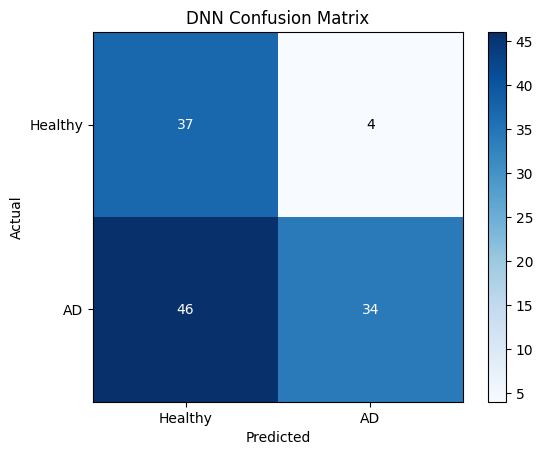

In [ ]:
cm = np.array([[tn, fp],
               [fn, tp]])

plt.imshow(cm, cmap='Blues')
plt.title("DNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0,1], ["Healthy","AD"])
plt.yticks([0,1], ["Healthy","AD"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha='center',
                 va='center',
                 color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.colorbar()
plt.show()